In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/heart.csv")
df_eda = df.copy()

In [3]:
df_eda.sample()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
208,28,M,ATA,130,132,0,LVH,185,N,0.0,Up,0


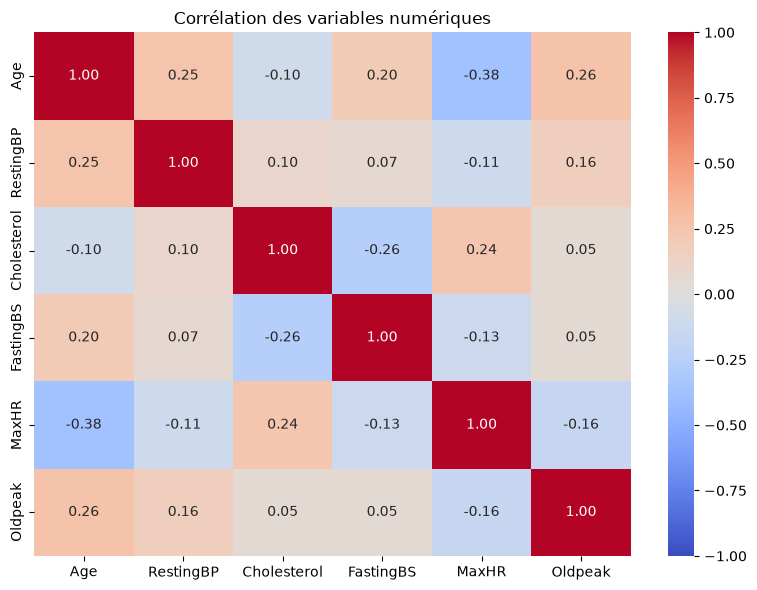

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns 

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS','MaxHR', 'Oldpeak']

corr_matrix = df_eda[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Corrélation des variables numériques')
plt.tight_layout()
plt.savefig('../figures/Corrélation_des_variables_numériques.png', dpi=300, bbox_inches='tight')
plt.show()

<Axes: >

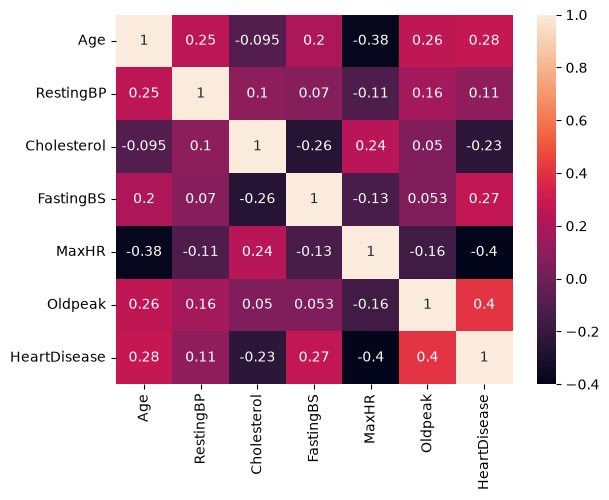

In [5]:
sns.heatmap(df_eda.corr(numeric_only=True),annot=True)

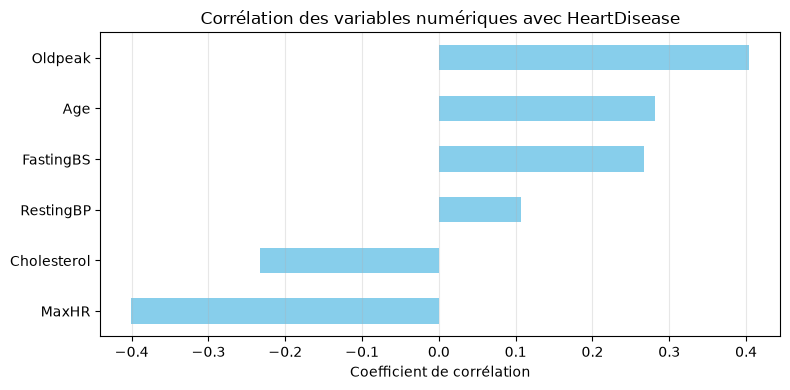

In [7]:
corr_num = df_eda[num_cols].corrwith(df_eda['HeartDisease']).sort_values()

plt.figure(figsize=(8, 4))
corr_num.plot(kind='barh', color='skyblue')
plt.title('Corrélation des variables numériques avec HeartDisease')
plt.xlabel('Coefficient de corrélation')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/Corrélation_des_variables_numériques_avec_HeartDisease.png', dpi=300, bbox_inches='tight')
plt.show()

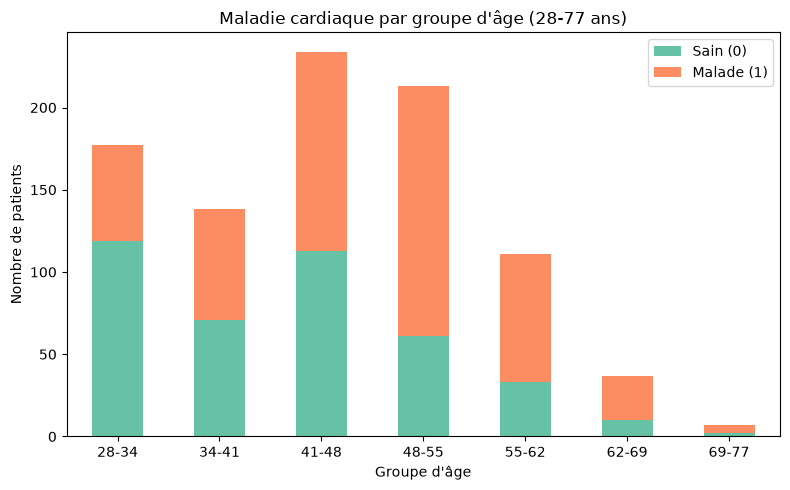

In [8]:
bins = [28,44,50,56,62,68,74,80]
labels = ['28-34', '34-41', '41-48','48-55','55-62','62-69','69-77']
df_eda['Age_group'] = pd.cut(df_eda['Age'], bins=bins, labels=labels, right=True)  

ct = pd.crosstab(df_eda['Age_group'], df_eda['HeartDisease'])

ct.plot(kind='bar', stacked=True, color=['#66c2a5', '#fc8d62'], figsize=(8,5))
plt.title('Maladie cardiaque par groupe d\'âge (28-77 ans)')
plt.xlabel('Groupe d\'âge')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
plt.legend(['Sain (0)', 'Malade (1)'])
plt.tight_layout()
plt.savefig('../figures/Maladie_cardiaque_par_groupe_d_âge.png', dpi=300, bbox_inches='tight')
plt.show()

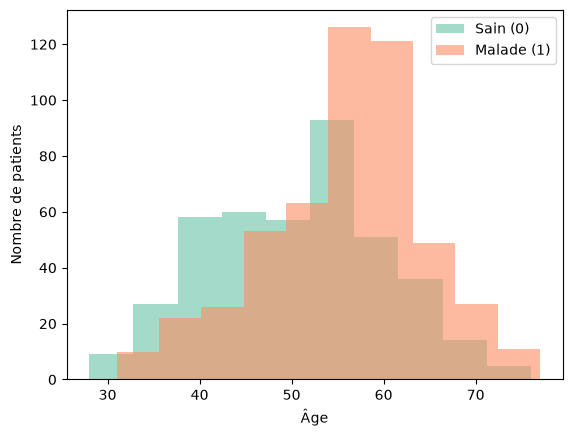

In [9]:
plt.hist(df_eda[df_eda['HeartDisease'] == 0]['Age'], alpha=0.6, label='Sain (0)', color='#66c2a5')
plt.hist(df_eda[df_eda['HeartDisease'] == 1]['Age'], alpha=0.6, label='Malade (1)', color='#fc8d62')
plt.xlabel('Âge')
plt.ylabel('Nombre de patients')
plt.legend()
plt.show()

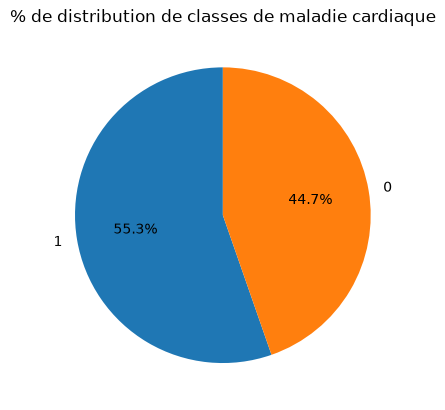

In [10]:
counts = df_eda['HeartDisease'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.title('% de distribution de classes de maladie cardiaque')
plt.savefig('../figures/distribution_de_classes.png', dpi=300, bbox_inches='tight')
plt.show()

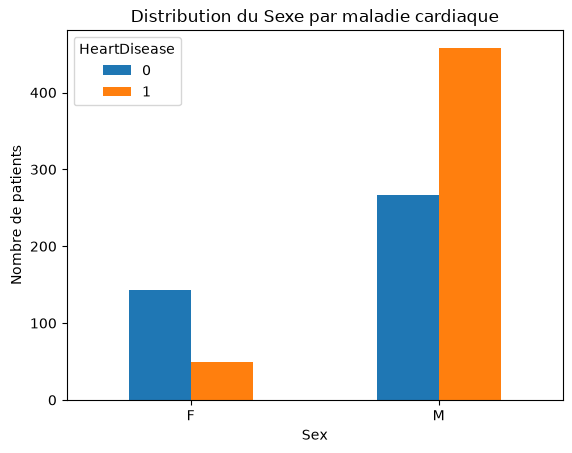

In [11]:
pd.crosstab(df_eda['Sex'], df_eda['HeartDisease']).plot(kind='bar')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
plt.title('Distribution du Sexe par maladie cardiaque')
plt.savefig('../figures/Distribution_du_Sexe_par_maladie_cardiaque.png', dpi=300, bbox_inches='tight')
plt.show()

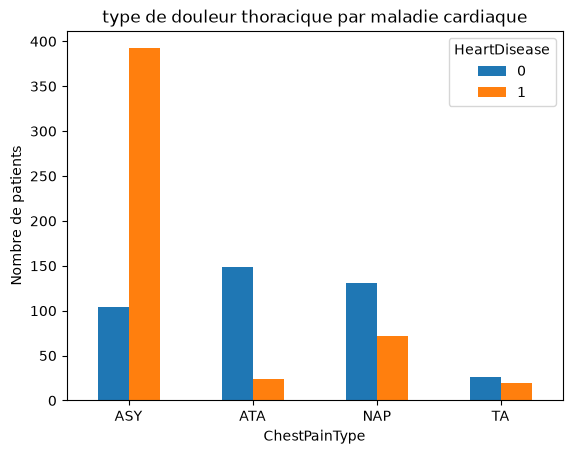

In [12]:
pd.crosstab(df_eda['ChestPainType'], df_eda['HeartDisease']).plot(kind='bar')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
plt.title('type de douleur thoracique par maladie cardiaque')
plt.savefig('../figures/type_de_douleur_thoracique_par_maladie_cardiaque.png', dpi=300, bbox_inches='tight')
plt.show()

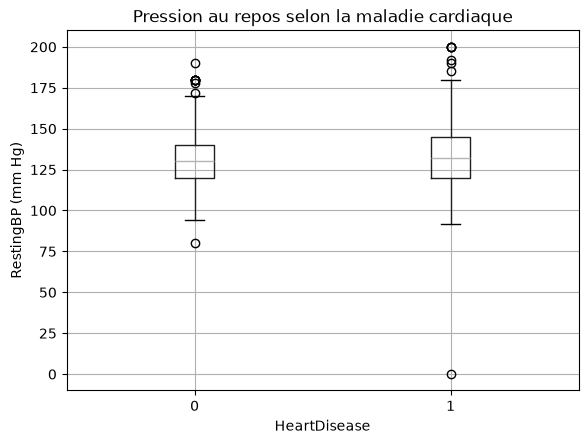

In [13]:
df_eda.boxplot(column='RestingBP', by='HeartDisease')
plt.title('Pression au repos selon la maladie cardiaque')
plt.suptitle('')
plt.ylabel('RestingBP (mm Hg)')
plt.show() 

<Axes: xlabel='FastingBS', ylabel='count'>

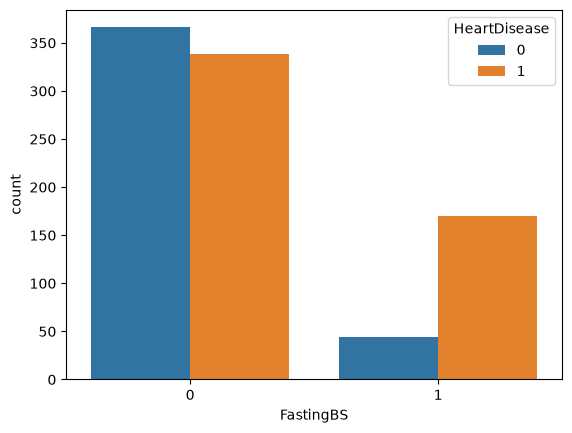

In [14]:
sns.countplot(x = df_eda['FastingBS'],hue = df_eda['HeartDisease'])

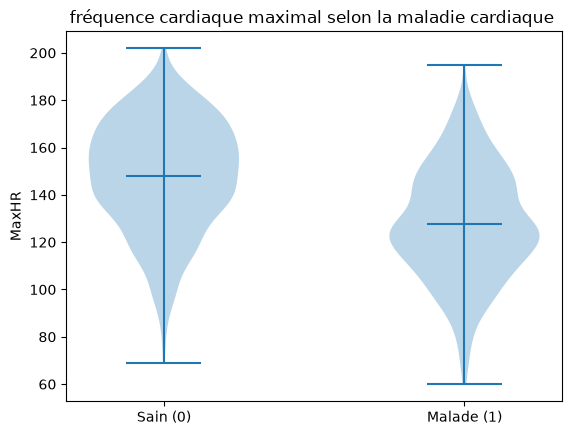

In [15]:
data = [
    df_eda[df_eda['HeartDisease'] == 0]['MaxHR'],
    df_eda[df_eda['HeartDisease'] == 1]['MaxHR']
]

plt.violinplot(data, positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Sain (0)', 'Malade (1)'])
plt.ylabel('MaxHR')
plt.title('fréquence cardiaque maximal selon la maladie cardiaque ')
plt.savefig('../figures/fréquence_cardiaque_maximal_selon_la_maladie_cardiaque.png', dpi=300, bbox_inches='tight')
plt.show()

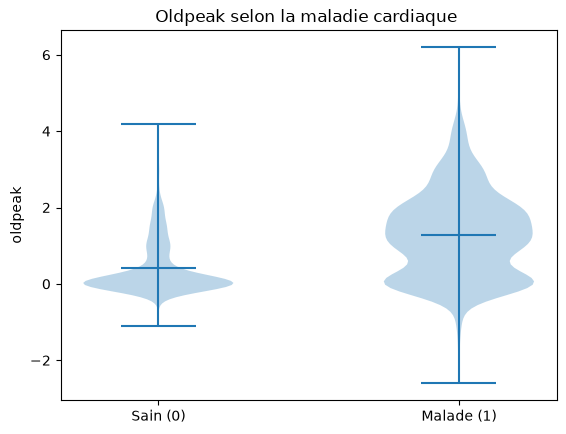

In [16]:
data = [
    df_eda[df_eda['HeartDisease'] == 0]['Oldpeak'],
    df_eda[df_eda['HeartDisease'] == 1]['Oldpeak']
]

plt.violinplot(data, positions=[0, 1], showmeans=True)
plt.xticks([0, 1], ['Sain (0)', 'Malade (1)'])
plt.ylabel('oldpeak')
plt.title('Oldpeak selon la maladie cardiaque ')
plt.savefig('../figures/Oldpeak_selon_la_maladie_cardiaque.png', dpi=300, bbox_inches='tight')
plt.show()

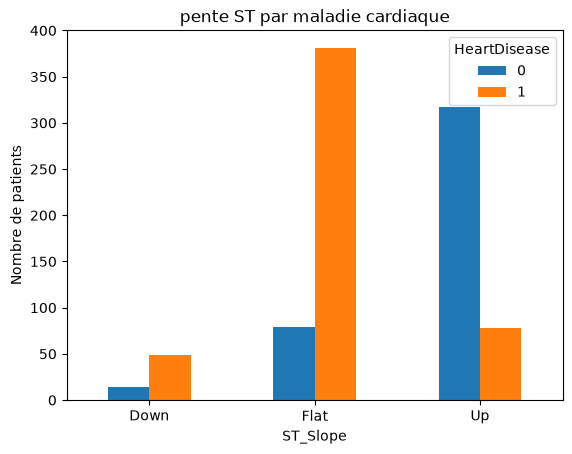

In [17]:
pd.crosstab(df_eda['ST_Slope'], df_eda['HeartDisease']).plot(kind='bar')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
plt.title('pente ST par maladie cardiaque')
plt.savefig('../figures/pente_ST_par_maladie_cardiaque.png', dpi=300, bbox_inches='tight')
plt.show()

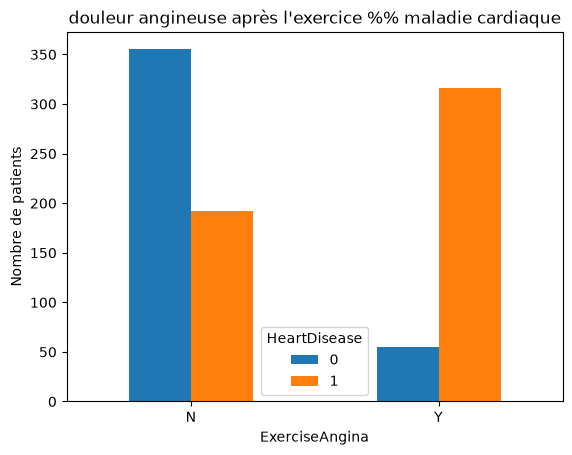

In [18]:
pd.crosstab(df_eda['ExerciseAngina'], df_eda['HeartDisease']).plot(kind='bar')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=0)
plt.title('douleur angineuse après l\'exercice %% maladie cardiaque')
plt.savefig('../figures/ExerciseAngina_par_maladie_cardiaque.png', dpi=300, bbox_inches='tight')
plt.show()

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

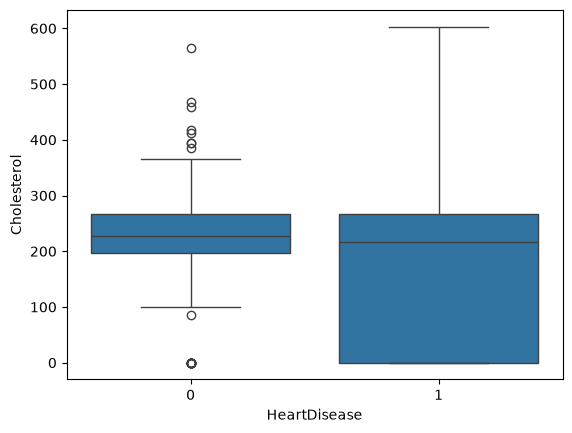

In [19]:
sns.boxplot(x='HeartDisease',y='Cholesterol',data=df_eda)

<Axes: xlabel='HeartDisease', ylabel='Age'>

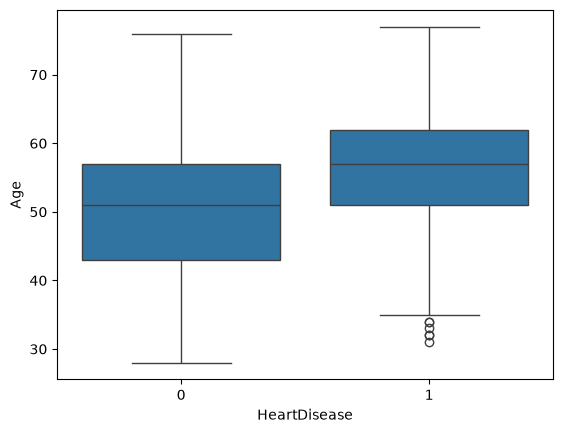

In [20]:
sns.boxplot(x='HeartDisease',y='Age',data=df_eda)

<Axes: xlabel='HeartDisease', ylabel='Age'>

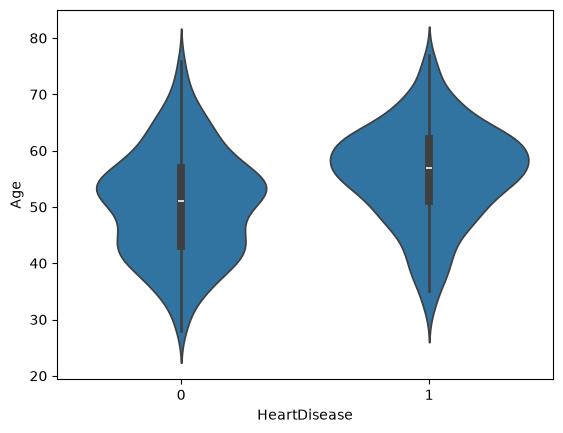

In [21]:
sns.violinplot(x='HeartDisease',y='Age',data=df_eda)

In [22]:
df_eda = df_eda.drop(columns=['Age_group'])

In [61]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [62]:
df_encoded.dtypes

Age                  float64
RestingBP            float64
Cholesterol          float64
FastingBS            float64
MaxHR                float64
Oldpeak              float64
HeartDisease           int64
Sex_M                   bool
ChestPainType_ATA       bool
ChestPainType_NAP       bool
ChestPainType_TA        bool
RestingECG_Normal       bool
RestingECG_ST           bool
ExerciseAngina_Y        bool
ST_Slope_Flat           bool
ST_Slope_Up             bool
dtype: object

In [63]:
bool_cols = df_encoded.select_dtypes(include=['bool']).columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [64]:
df_encoded.dtypes

Age                  float64
RestingBP            float64
Cholesterol          float64
FastingBS            float64
MaxHR                float64
Oldpeak              float64
HeartDisease           int64
Sex_M                  int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
RestingECG_Normal      int64
RestingECG_ST          int64
ExerciseAngina_Y       int64
ST_Slope_Flat          int64
ST_Slope_Up            int64
dtype: object

In [65]:
df_encoded.to_csv("../data/processed/heart_clean.csv",index=False)